In [1]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
### Loading the data
class_=pd.read_csv("classification_data.csv")

In [3]:
### Creating a duplicate of the data
farm_data = class_.copy()

In [4]:
### Inspecting the data
farm_data.head(20)

,Date,Region,Crop_Type,Rainfall_mm,Temperature_C,Soil_Moisture,Fertilizer_Used,Pest_Presence,Disease_Presence
0,1/1/2022,Greater Accra,Rice,30.63,27.1,0.43,Yes,0.0,0.0
1,1/2/2022,Northern,Cocoa,37.38,25.5,0.20,Yes,0.0,1.0
2,1/2/2022,Volta,Cassava,43.34,30.2,0.48,Yes,0.0,1.0
3,1/2/2022,Western,Rice,60.45,26.9,0.62,No,1.0,1.0
4,1/2/2022,Western,Cassava,63.69,28.7,0.56,Yes,1.0,1.0
5,1/3/2022,Ashanti,Rice,46.55,29.9,0.33,Yes,0.0,0.0
6,1/3/2022,Northern,Cocoa,27.22,32.5,0.28,No,0.0,1.0
7,1/3/2022,Ashanti,Rice,54.23,24.3,0.63,No,1.0,1.0
8,1/3/2022,Western,Maize,44.80,31.0,0.54,Yes,0.0,1.0
9,1/4/2022,Northern,Maize,34.82,28.7,0.17,Yes,1.0,1.0


In [5]:
### Checking the columns
farm_data.columns

Index(['Date', 'Region', 'Crop_Type', 'Rainfall_mm', 'Temperature_C',
       'Soil_Moisture', 'Fertilizer_Used', 'Pest_Presence',
       'Disease_Presence'],
      dtype='object')

In [6]:
### Checking the data types
farm_data.dtypes

Date                 object
Region               object
Crop_Type            object
Rainfall_mm         float64
Temperature_C       float64
Soil_Moisture       float64
Fertilizer_Used      object
Pest_Presence       float64
Disease_Presence    float64
dtype: object

In [7]:
### Checking for missing values
farm_data.isnull().sum()

Date                 0
Region              12
Crop_Type           17
Rainfall_mm         15
Temperature_C       21
Soil_Moisture       16
Fertilizer_Used     16
Pest_Presence        5
Disease_Presence     7
dtype: int64

In [8]:
### Grroup numeric values only
num_farm = farm_data.select_dtypes(include="number").drop(columns = ["Pest_Presence", "Disease_Presence"])
num_farm

,Rainfall_mm,Temperature_C,Soil_Moisture
0,30.63,27.1,0.43
1,37.38,25.5,0.20
2,43.34,30.2,0.48
3,60.45,26.9,0.62
4,63.69,28.7,0.56
...,...,...,...
2195,27.03,32.8,0.37
2196,45.73,28.8,0.51
2197,26.18,29.3,0.10
2198,52.86,31.4,0.47


In [9]:
### calling for simple descriptive information from the data
farm_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              2200 non-null   object 
 1   Region            2188 non-null   object 
 2   Crop_Type         2183 non-null   object 
 3   Rainfall_mm       2185 non-null   float64
 4   Temperature_C     2179 non-null   float64
 5   Soil_Moisture     2184 non-null   float64
 6   Fertilizer_Used   2184 non-null   object 
 7   Pest_Presence     2195 non-null   float64
 8   Disease_Presence  2193 non-null   float64
dtypes: float64(5), object(4)
memory usage: 154.8+ KB


In [10]:
### Calling for summary statistics from the data
farm_data.describe()

,Rainfall_mm,Temperature_C,Soil_Moisture,Pest_Presence,Disease_Presence
count,2185.000000,2179.000000,2184.000000,2195.000000,2193.000000
mean,137.672838,27.384397,0.438219,0.428246,0.754218
std,96.924269,2.841347,0.144069,0.494937,0.430648
min,12.390000,18.900000,0.100000,0.000000,0.000000
25%,45.460000,25.300000,0.330000,0.000000,1.000000
50%,128.120000,27.200000,0.430000,0.000000,1.000000
75%,216.250000,29.300000,0.540000,1.000000,1.000000
max,431.380000,37.600000,0.700000,1.000000,1.000000


In [11]:
num_farm.describe()

,Rainfall_mm,Temperature_C,Soil_Moisture
count,2185.000000,2179.000000,2184.000000
mean,137.672838,27.384397,0.438219
std,96.924269,2.841347,0.144069
min,12.390000,18.900000,0.100000
25%,45.460000,25.300000,0.330000
50%,128.120000,27.200000,0.430000
75%,216.250000,29.300000,0.540000
max,431.380000,37.600000,0.700000


# Exploratory Data Analaysis (EDA)

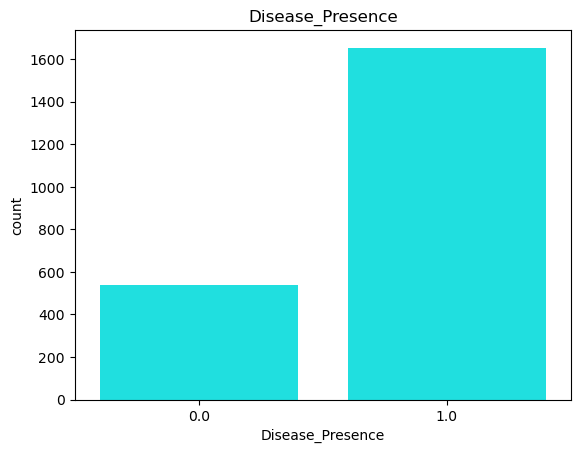

In [12]:
### Visualize the target variable
#farm["Disease_Presence"]
sns.countplot(x= "Disease_Presence", data = farm_data, color="cyan")
plt.title("Disease_Presence")
plt.show()

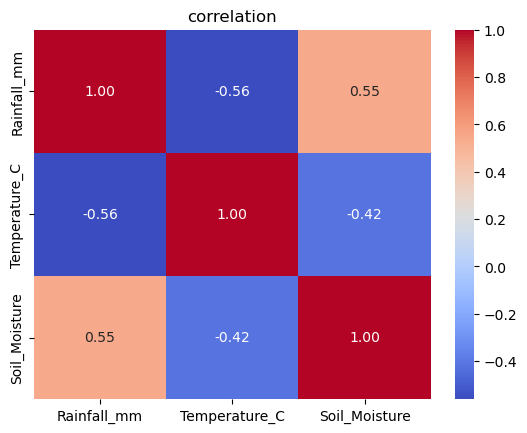

In [13]:
### Visualizing the coefficient
sns.heatmap(num_farm.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("correlation")
plt.show()

In [14]:
num_list=num_farm.columns.to_list()

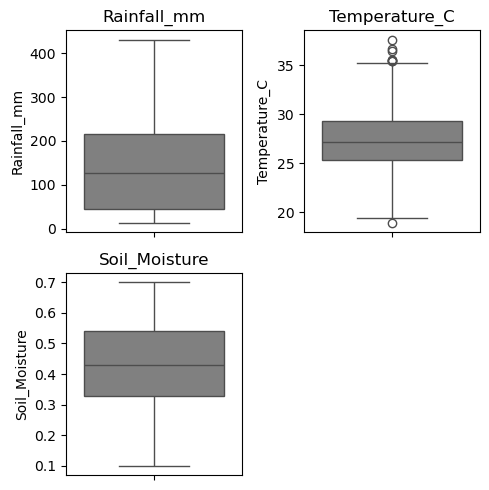

In [15]:
### Boxplot
plt.figure(figsize=(5,5))
for index, col in enumerate (num_list, start=1):
    plt.subplot(2,2, index)
    sns.boxplot(num_farm[col], color= "grey")
    plt.title(col)
plt.tight_layout()
plt.show()

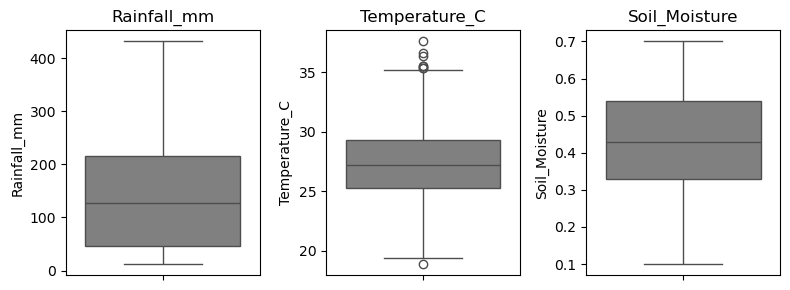

In [16]:
### Boxplot
plt.figure(figsize=(8,3))
for index, col in enumerate (num_list, start=1):
    plt.subplot(1,3, index)
    sns.boxplot(num_farm[col], color= "grey")
    plt.title(col)
plt.tight_layout()
plt.show()

In [17]:
### IQR
outlier_container={}
for col in num_list:
    Q1=num_farm[col].quantile(0.25)
    Q3=num_farm[col].quantile(0.75)
    IQR= Q3-Q1
    lower_bound = Q1-1.5*IQR
    upper_bound = Q3 + 1.5*IQR
    outliers = num_farm[(num_farm[col]<=lower_bound) | (num_farm[col]>=upper_bound)][col] # collects all the outliers into the outliers variable
    outlier_container.update({col:outliers})

In [18]:
### Unpack the dictionary
for item, value in outlier_container.items():
    print(f"{item}: {len(value)} outliers")

Rainfall_mm: 0 outliers
Temperature_C: 8 outliers
Soil_Moisture: 0 outliers


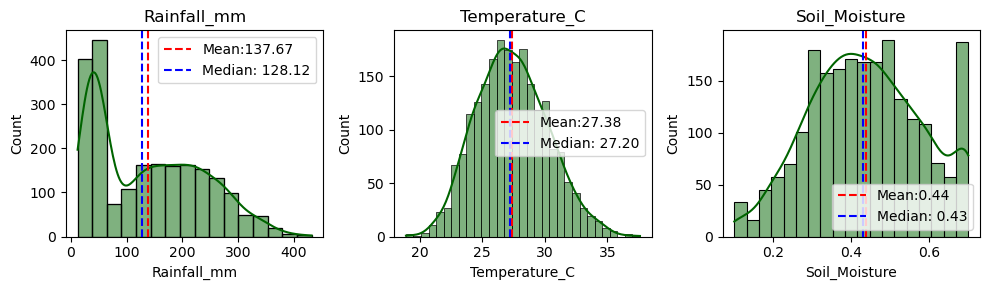

In [19]:
### Histogram Plot
plt.figure(figsize=(10,3))
for index, col in enumerate (num_list, start=1):
    plt.subplot(1,3, index)
    sns.histplot(num_farm[col], kde=True, color="darkgreen")
    mean_line = num_farm[col].mean()
    median_line = num_farm[col].median()
    plt.axvline(mean_line, linestyle= "--", color = "red", label = f"Mean:{mean_line:.2f}")
    plt.axvline(median_line, linestyle = "--", color = "blue", label = f"Median: {median_line:.2f}")
    plt.title(col)
    plt.legend()
plt.tight_layout()
plt.show()
    

# Feature Engineering

In [20]:
farm_data["Date"] = pd.to_datetime(farm_data["Date"], format = "%m/%d/%Y")

In [21]:
print(farm_data["Date"].dtype)

datetime64[ns]


In [22]:
farm_data["Month"] = farm_data["Date"].dt.month

In [23]:
farm_data["Season"] = farm_data["Month"].apply(lambda month: 1 if 4 <= month <= 10 else 0)

# Feature Selection

In [24]:
farm_data.columns

Index(['Date', 'Region', 'Crop_Type', 'Rainfall_mm', 'Temperature_C',
       'Soil_Moisture', 'Fertilizer_Used', 'Pest_Presence', 'Disease_Presence',
       'Month', 'Season'],
      dtype='object')

In [25]:
### Selecting the independent variables
### To do this, we only keep the relevant variables and drop the irrelevant variables
#X = farm_data.drop(columns = ["Date", "Disease_Presence", "Month"])

### Selecting the outcome or target variable
#y = farm_data["Disease_Presence"]
#Because of missing observations, we are unable to use this approach

In [26]:
farm_data.isnull().sum()

Date                 0
Region              12
Crop_Type           17
Rainfall_mm         15
Temperature_C       21
Soil_Moisture       16
Fertilizer_Used     16
Pest_Presence        5
Disease_Presence     7
Month                0
Season               0
dtype: int64

In [27]:
### Exclude the missing values from the target variable
farm_notna=farm_data[farm_data["Disease_Presence"].notna()]

In [28]:
### Selecting independent and dependent variables from the data in which missing variables have been excluded
X = farm_notna.drop(columns = ["Date", "Disease_Presence", "Month"])
y = farm_notna ["Disease_Presence"]

In [29]:
y

0       0.0
1       1.0
2       1.0
3       1.0
4       1.0
       ... 
2195    0.0
2196    0.0
2197    1.0
2198    0.0
2199    1.0
Name: Disease_Presence, Length: 2193, dtype: float64

In [30]:
# Data Transfprmation
# Spliting the data first
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42, stratify = y)

In [31]:
print (X_train.shape)
print(X_test.shape)

(1754, 8)
(439, 8)


In [32]:
### Group the objects and numeric types
X_train.select_dtypes(include="number")

,Rainfall_mm,Temperature_C,Soil_Moisture,Pest_Presence,Season
2194,70.08,26.2,0.45,1.0,0
125,46.88,29.5,NaN,1.0,0
702,286.43,26.8,0.55,1.0,1
643,210.22,23.4,0.46,0.0,1
254,33.49,31.3,0.33,0.0,0
...,...,...,...,...,...
1405,152.07,30.1,0.19,0.0,1
852,123.49,25.1,0.39,1.0,1
1377,42.37,28.9,0.34,0.0,0
601,271.44,22.1,0.62,0.0,1


In [33]:
X_train.isnull().sum()

Region              9
Crop_Type          12
Rainfall_mm         9
Temperature_C      13
Soil_Moisture      10
Fertilizer_Used    10
Pest_Presence       3
Season              0
dtype: int64

In [34]:
### Group the objects and numeric types
## But because the Pest_Presence is binary/dummy, we cant fill it. hence we exclude them
### Treating Numerical data types
num_list = X_train.select_dtypes(include="number").drop(columns = "Pest_Presence").columns.to_list()
### Treating categorical datat types
cat_list = X_train.select_dtypes(include="object").columns.to_list()


In [35]:
print(num_list)
print(cat_list)

['Rainfall_mm', 'Temperature_C', 'Soil_Moisture', 'Season']
['Region', 'Crop_Type', 'Fertilizer_Used']


In [36]:
### Group the objects and numeric types
## But because the Pest_Presence is binary/dummy, we cant fill it. hence we exclude them
### Treating Numerical data types
num_list = X_train.select_dtypes(include="number").drop(columns = "Pest_Presence").columns.to_list()
### Treating categorical datat types
cat_list = X_train.select_dtypes(include="object").columns.to_list()
### We have to work on the Pest_Presence variable
pest_col = ["Pest_Presence"]

### SMOTE (Synthetic Minority Oversampling Technique)

In [37]:
from imblearn.pipeline import Pipeline # To build the pipe line
from sklearn.impute import SimpleImputer # For imputing the missing values
from sklearn.preprocessing import StandardScaler # Stndardizing the varaibles
from sklearn.preprocessing import OneHotEncoder # for encoding categorical variables
from sklearn.compose import ColumnTransformer # It transforms columns
from imblearn.over_sampling import SMOTE # used to create synthetic data points to balance the distribution of the variables of interest in the data

In [38]:
### Focus on the numeric part
num_steps = Pipeline([("impute", SimpleImputer(strategy = "mean")), ("scaling", StandardScaler())])

### Focusing on categorical part
cat_steps = Pipeline([("impute", SimpleImputer (strategy = "most_frequent")),
                     ("encode", OneHotEncoder(drop="first"))])
pest_steps = Pipeline ([("impute", SimpleImputer(strategy = "most_frequent"))])

In [39]:
### Use the column transformer to identify and effect changes to the columns
preprocessor = ColumnTransformer([("num_transform", num_steps, num_list), ("cat_transform", cat_steps, cat_list),
                  ("pest_transform", pest_steps, pest_col)])

# Model Selection

In [40]:
from sklearn.linear_model import LogisticRegression


In [41]:
### Applying the transformation on the data and speciffying the estimation technqiue the machine has to use
model_log = Pipeline([("column_transform", preprocessor), ("smote", SMOTE(random_state=42)), 
          ("classifier", LogisticRegression())])

In [42]:
### traning the machine/fit the model
model_log.fit(X_train, y_train)

Pipeline(steps=[('column_transform',
                 ColumnTransformer(transformers=[('num_transform',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer()),
                                                                  ('scaling',
                                                                   StandardScaler())]),
                                                  ['Rainfall_mm',
                                                   'Temperature_C',
                                                   'Soil_Moisture', 'Season']),
                                                 ('cat_transform',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encode',
                                                                   OneHotEncoder(drop='first'))]),
                                                  ['Region', 'Crop_Type',
                                                   'Fertilizer_Used']),
                                                 ('pest_transform',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['Pest_Presence'])])),
                ('smote', SMOTE(random_state=42)),
                ('classifier', LogisticRegression())])

In [43]:
### predicting using the model
y_pred_log = model_log.predict(X_test)

# Evaluating our model

In [44]:
### using the classification report. It gives details on how well the machine performed in prediction the outcome
from sklearn.metrics import classification_report ## It gives on the performance of the machine
print (classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

         0.0       0.39      0.70      0.50       108
         1.0       0.87      0.63      0.73       331

    accuracy                           0.65       439
   macro avg       0.63      0.67      0.62       439
weighted avg       0.75      0.65      0.68       439



In [45]:
### Precision:- of all the positive predictions, how many of the positives werre actually right
### Precision = TP/(TP+FP)
### False Positive is Type I error
### 

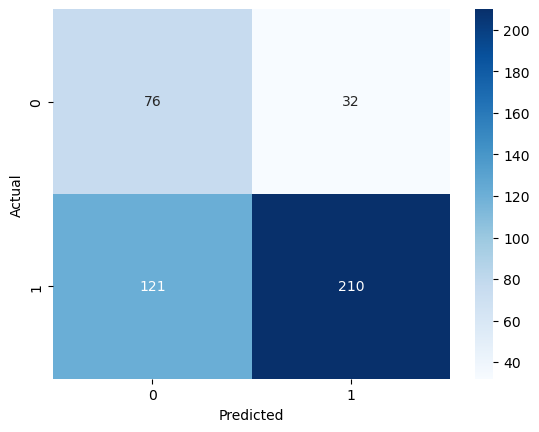

In [46]:
###  Confusion Matrix
from sklearn.metrics import confusion_matrix # It gives a visualization of how the machine did the prediction
cm = confusion_matrix (y_test, y_pred_log)
sns.heatmap(cm, annot=True, cmap = "Blues", fmt = "d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [47]:
### Inspecting the distribution of the disease presence variable
### Frequencies
farm_data ["Disease_Presence"].value_counts()

Disease_Presence
1.0    1654
0.0     539
Name: count, dtype: int64

In [48]:
### Inspecting the distribution of the disease presence variable
### Proportions
farm_data ["Disease_Presence"].value_counts(normalize=True)

Disease_Presence
1.0    0.754218
0.0    0.245782
Name: proportion, dtype: float64

In [49]:
### Using Accuracy Score to evaluate the performance of the model
from sklearn.metrics import accuracy_score
print (accuracy_score(y_test, y_pred_log))

0.6514806378132119


In [50]:
#### Test Dataset
#test_rmse_lr = np.sqrt(mean_squared_error(y_test, y_test_lr))
#test_mae_lr = mean_absolute_error(y_test, y_test_lr)
#test_r2_lr = r2_score(y_test, y_test_lr)

In [51]:
#### Display the evaluation metrics
#print("\nTest")
#print("RMSE:", test_rmse_lr)
#print("MAE:", test_mae_lr)
#print("R2-square:", test_r2_lr)

# Decision Tree

In [52]:
from sklearn.tree import DecisionTreeClassifier

In [53]:
model_tree = Pipeline([("column_transform", preprocessor), ("smote", SMOTE(random_state=42)), 
          ("classifier", DecisionTreeClassifier())])

In [54]:
### Fit the model
model_tree.fit(X_train, y_train)

Pipeline(steps=[('column_transform',
                 ColumnTransformer(transformers=[('num_transform',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer()),
                                                                  ('scaling',
                                                                   StandardScaler())]),
                                                  ['Rainfall_mm',
                                                   'Temperature_C',
                                                   'Soil_Moisture', 'Season']),
                                                 ('cat_transform',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encode',
                                                                   OneHotEncoder(drop='first'))]),
                                                  ['Region', 'Crop_Type',
                                                   'Fertilizer_Used']),
                                                 ('pest_transform',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['Pest_Presence'])])),
                ('smote', SMOTE(random_state=42)),
                ('classifier', DecisionTreeClassifier())])

In [55]:
### Use it for prediction
y_pred_tree = model_tree.predict(X_test)
y_pred_tree_train = model_tree.predict(X_train)

In [56]:
### Evaluate the model
print(accuracy_score(y_test, y_pred_tree))
print(accuracy_score(y_train, y_pred_tree_train))

0.6719817767653758
1.0


In [57]:
print (classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

         0.0       0.37      0.46      0.41       108
         1.0       0.81      0.74      0.77       331

    accuracy                           0.67       439
   macro avg       0.59      0.60      0.59       439
weighted avg       0.70      0.67      0.68       439



In [58]:
print (confusion_matrix(y_test, y_pred_tree))

[[ 50  58]
 [ 86 245]]


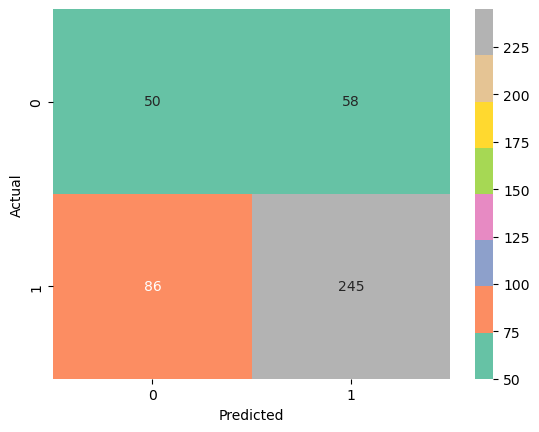

In [59]:
cm = confusion_matrix(y_test, y_pred_tree)
sns.heatmap(cm, annot=True, cmap = "Set2", fmt = "d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Rabdom Forest

In [60]:
from sklearn.ensemble import RandomForestClassifier

In [61]:
model_forest = Pipeline([("column_transform", preprocessor), ("smote", SMOTE(random_state=42)), 
          ("classifier", RandomForestClassifier())])

In [62]:
### Fit the model
model_forest.fit(X_train, y_train)

Pipeline(steps=[('column_transform',
                 ColumnTransformer(transformers=[('num_transform',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer()),
                                                                  ('scaling',
                                                                   StandardScaler())]),
                                                  ['Rainfall_mm',
                                                   'Temperature_C',
                                                   'Soil_Moisture', 'Season']),
                                                 ('cat_transform',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encode',
                                                                   OneHotEncoder(drop='first'))]),
                                                  ['Region', 'Crop_Type',
                                                   'Fertilizer_Used']),
                                                 ('pest_transform',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['Pest_Presence'])])),
                ('smote', SMOTE(random_state=42)),
                ('classifier', RandomForestClassifier())])

In [63]:
### Use it for prediction
y_pred_forest = model_forest.predict(X_test)

In [64]:
### Evaluate the model
print(accuracy_score(y_test, y_pred_forest))

0.7220956719817767


In [65]:
print (classification_report(y_test, y_pred_forest))

              precision    recall  f1-score   support

         0.0       0.44      0.48      0.46       108
         1.0       0.83      0.80      0.81       331

    accuracy                           0.72       439
   macro avg       0.63      0.64      0.64       439
weighted avg       0.73      0.72      0.73       439



# XGBoost

In [ ]:
#pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
Note: you may need to restart the kernel to use updated packages.


In [70]:
from xgboost import XGBClassifier

In [ ]:
model_xgb = Pipeline([("column_transform", preprocessor), ("smote", SMOTE(random_state=42)), 
          ("classifier", XGBClassifier())])

In [ ]:
### Fit the model
model_xgb.fit(X_train, y_train)

Pipeline(steps=[('column_transform',
                 ColumnTransformer(transformers=[('num_transform',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer()),
                                                                  ('scaling',
                                                                   StandardScaler())]),
                                                  ['Rainfall_mm',
                                                   'Temperature_C',
                                                   'Soil_Moisture', 'Season']),
                                                 ('cat_transform',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encode',
                                                                   OneHotEncoder(drop='first'))]),
                                                  ['Region...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [ ]:
### Use it for prediction
y_pred_xgb = model_xgb.predict(X_test)

In [ ]:
### Evaluate the model
print(accuracy_score(y_test, y_pred_xgb))

0.715261958997722


In [ ]:
print (classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

         0.0       0.42      0.44      0.43       108
         1.0       0.81      0.81      0.81       331

    accuracy                           0.72       439
   macro avg       0.62      0.62      0.62       439
weighted avg       0.72      0.72      0.72       439



# Feature Importance

In [ ]:
### Using Random Forest

In [ ]:
param_model = model_forest.named_steps["classifier"]

In [ ]:
feature_names = model_forest.named_steps["column_transform"].get_feature_names_out()

In [ ]:
coef = param_model.feature_importances_

In [ ]:
feature_df = pd.DataFrame({"Features": feature_names, "Values": coef})
feature_df.head(4)

,Features,Values
0,num_transform__Rainfall_mm,0.224870
1,num_transform__Temperature_C,0.187251
2,num_transform__Soil_Moisture,0.211453
3,num_transform__Season,0.024112


In [ ]:
feature_df["Features"] = feature_df["Features"].str.split("__").str[1]

In [ ]:
feature_df.head(4)

,Features,Values
0,Rainfall_mm,0.224870
1,Temperature_C,0.187251
2,Soil_Moisture,0.211453
3,Season,0.024112


In [ ]:
feature_df["Features"] = feature_df["Features"].str.split("_").str[:2].str.join("_")

In [ ]:
feature_df.groupby("Features")["Values"].sum().sort_values(ascending=True)

Features
Region_Greater Accra    0.015877
Region_Volta            0.021843
Region_Northern         0.023641
Season                  0.024112
Region_Western          0.024681
Fertilizer_Used         0.045459
Pest_Presence           0.095158
Crop_Type               0.125655
Temperature_C           0.187251
Soil_Moisture           0.211453
Rainfall_mm             0.224870
Name: Values, dtype: float64

In [ ]:
feature_df.loc[feature_df["Features"]=="Region_Northern", "Features"]="Northern"
feature_df.loc[feature_df["Features"]=="Region_Western", "Features"]="Western"
feature_df.loc[feature_df["Features"]=="Region_Volta", "Features"]="Volta"
feature_df.loc[feature_df["Features"]=="Region_Greater Accra", "Features"]="Accra"

In [ ]:
grouped_features=feature_df.groupby("Features")["Values"].sum().sort_values(ascending=True)

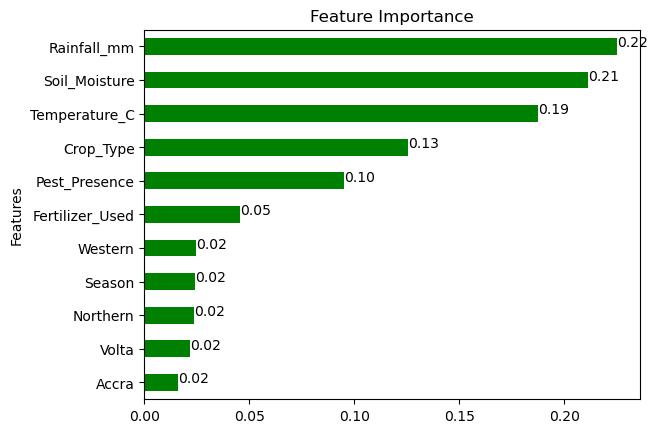

In [ ]:
grouped_features.plot(kind="barh", color = "g")
plt.title("Feature Importance")
## Add labels
for x, y in enumerate(grouped_features):
    plt.text(y, x, f"{y:.2f}")

plt.show()

# Crosss Validation

### K-Fold Cross Validation

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

In [ ]:
### Setting up your cross validation
cross_validate = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

In [ ]:
### Perform the training
scores = cross_val_score(model_forest, X_train, y_train,cv = cross_validate,  scoring = "f1")

In [ ]:
### print the mean and standard deviation
print (f"Mean: {scores.mean()}")
print(f"Standard Deviation: {scores.std()}")

Mean: 0.8344447595988568
Standard Deviation: 0.011267014678300795


# Hyperparameter Tuning
- Using the random forest

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
### Using the random forest os the best model
random_grid = {
"classider_n_estimators" : [50, 100],
"classider_max_depth" : [3,5, None],
"classider_min_sample_split" : [2,5],
"classider_min_sample_leaf" : [1,2,5],
"classider_class_weight" : ["balanced"]}

In [ ]:
search_grid = GridSearchCV (model_forest, param_grid = random_grid, cv = 5)

# ROC_AUC

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve

In [ ]:
y_probab = model_forest.predict_proba(X_test)[:,1]

In [ ]:
print (roc_auc_score(y_test, y_probab))

0.715508559919436


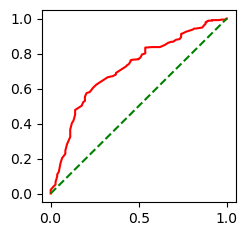

In [ ]:
### Visualize the ROC
TPR, FPR, threshold = roc_curve(y_test, y_probab)
plt.figure(figsize=(2.5,2.5))
plt.plot(TPR, FPR, color = "r")
plt.plot([0,1],[0,1], linestyle = "--", color = "g")
plt.show()